In [1]:
import sqlite3
import pandas as pd

In [4]:
sql = sqlite3.connect('C:\\Users\\User\\Documents\\ДЗ\\football.db')

In [57]:
names = [
    'Cristiano Ronaldu',
    'Lionel Messi',
    'Luca Modrich',
    'Dzanluidji de Buffon',
    'Kilian Mbape',
    'Artem Dzyba',
    'Matvey Savonov',
    
]
rating = [85, 86, 83, 91, 91, 78,79]
birth_dates = [
    '05.02.1985',
    '24.06.1987',
    '09.09.1985',
    '28.01.1978',
    '20.12.1998',
    '22.08.1988',
    '25.02.1999'
]
players_df = pd.DataFrame({'name': names, 'rating': rating, 'birth_date': birth_dates})


In [58]:
players_df.to_sql('players', sql, index_label="id", if_exists='replace')

7

In [59]:
pd.read_sql('SELECT * FROM players', sql)

,id,name,rating,birth_date
0,0,Cristiano Ronaldu,85,05.02.1985
1,1,Lionel Messi,86,24.06.1987
2,2,Luca Modrich,83,09.09.1985
3,3,Dzanluidji de Buffon,91,28.01.1978
4,4,Kilian Mbape,91,20.12.1998
5,5,Artem Dzyba,78,22.08.1988
6,6,Matvey Savonov,79,25.02.1999


In [60]:
names = [
    'Cristiano Ronaldu',
    'Lionel Messi',
    'Luca Modrich',
    'Dzanluidji de Buffon',
    'Kilian Mbape',
    'Artem Dzyba',
    'Matvey Savonov',
]
clubs = [
    'Al Nasr',
    'Inter Mayami',
    'Milan',
    'Juventus',
    'Real Madrid',
    'Акрон',
    'PSG'
]
clubs_df = pd.DataFrame({'name': names,'club': clubs})
clubs_df.to_sql('clubs', sql, index_label='id', if_exists='replace')

7

In [61]:
pd.read_sql('SELECT * FROM clubs', sql)

,id,name,club
0,0,Cristiano Ronaldu,Al Nasr
1,1,Lionel Messi,Inter Mayami
2,2,Luca Modrich,Milan
3,3,Dzanluidji de Buffon,Juventus
4,4,Kilian Mbape,Real Madrid
5,5,Artem Dzyba,Акрон
6,6,Matvey Savonov,PSG


In [62]:
clubs = [
    'Al Nasr',
    'Inter Mayami',
    'Milan',
    'Juventus',
    'Real Madrid',
    'Акрон',
    'PSG'
]
clubs_country = [
    'S.Aravia',
    'USA',
    'Italy',
    'Italy',
    'Spain',
    'Russia',
    'France'
]
clubs_country_df = pd.DataFrame({'club': clubs,'club_country': clubs_country})
clubs_country_df.to_sql('club_country', sql, index_label='id', if_exists='replace')

7

In [63]:
pd.read_sql('SELECT * FROM club_country', sql)

,id,club,club_country
0,0,Al Nasr,S.Aravia
1,1,Inter Mayami,USA
2,2,Milan,Italy
3,3,Juventus,Italy
4,4,Real Madrid,Spain
5,5,Акрон,Russia
6,6,PSG,France


In [64]:
names = [
    'Cristiano Ronaldu',
    'Lionel Messi',
    'Luca Modrich',
    'Dzanluidji de Buffon',
    'Kilian Mbape',
    'Artem Dzyba',
    'Matvey Savonov',
]
nationaluty = [
    'Португалия',
    'Аргентина',
    'Хорватия',
    'Италия',
    'Франция',
    'Россия',
    'Россия'
]
nationaluty_df = pd.DataFrame({'name': names,'nationaluty': nationaluty})
nationaluty_df.to_sql('nationaluty', sql, index_label='id', if_exists='replace')

7

In [65]:
pd.read_sql('''SELECT * FROM nationaluty  ''', sql)

,id,name,nationaluty
0,0,Cristiano Ronaldu,Португалия
1,1,Lionel Messi,Аргентина
2,2,Luca Modrich,Хорватия
3,3,Dzanluidji de Buffon,Италия
4,4,Kilian Mbape,Франция
5,5,Artem Dzyba,Россия
6,6,Matvey Savonov,Россия


In [66]:
pd.read_sql('''
SELECT 
players.id, players.name, players.rating, players.birth_date, clubs.club, club_country, nationaluty.nationaluty  
FROM players
JOIN clubs ON players.name=clubs.name
JOIN club_country ON clubs.club=club_country.club
JOIN nationaluty ON players.name=nationaluty.name
''', sql)

,id,name,rating,birth_date,club,club_country,nationaluty
0,0,Cristiano Ronaldu,85,05.02.1985,Al Nasr,S.Aravia,Португалия
1,1,Lionel Messi,86,24.06.1987,Inter Mayami,USA,Аргентина
2,2,Luca Modrich,83,09.09.1985,Milan,Italy,Хорватия
3,3,Dzanluidji de Buffon,91,28.01.1978,Juventus,Italy,Италия
4,4,Kilian Mbape,91,20.12.1998,Real Madrid,Spain,Франция
5,5,Artem Dzyba,78,22.08.1988,Акрон,Russia,Россия
6,6,Matvey Savonov,79,25.02.1999,PSG,France,Россия


In [67]:
pd.read_sql('''
with cte as(SELECT 
players.id, players.name, players.rating, players.birth_date, clubs.club, club_country, nationaluty.nationaluty,DENSE_RANK() over(partition by nationaluty order by rating desc) as top  
FROM players
JOIN clubs ON players.name=clubs.name
JOIN club_country ON clubs.club=club_country.club
JOIN nationaluty ON players.name=nationaluty.name )
Select * From cte
Where top=1 and nationaluty='Россия'

''', sql)## Находим лучшего по рейтингу русского игрока

,id,name,rating,birth_date,club,club_country,nationaluty,top
0,6,Matvey Savonov,79,25.02.1999,PSG,France,Россия,1


In [68]:
df = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\amazon_sales_dataset.csv') 
df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16


In [69]:
df.to_sql('amazon_sales_dataset', sql, index_label="id", if_exists='replace')

50000

In [70]:
a=pd.read_sql('''SELECT product_category,discount_percent,sum(quantity_sold),sum(total_revenue)
FROM amazon_sales_dataset
GROUP BY product_category,discount_percent''', sql)
a

,product_category,discount_percent,sum(quantity_sold),sum(total_revenue)
0,Beauty,0,4215,1063791.60
1,Beauty,5,4269,1038998.88
2,Beauty,10,4317,970724.27
3,Beauty,15,4203,889913.19
4,Beauty,20,4034,814538.56
5,Beauty,30,4384,772658.47
6,Books,0,3979,980230.12
7,Books,5,4423,1043450.07
8,Books,10,4265,1006652.94
9,Books,15,3918,829933.05


In [71]:
a[['discount_percent','sum(total_revenue)']]

,discount_percent,sum(total_revenue)
0,0,1063791.60
1,5,1038998.88
2,10,970724.27
3,15,889913.19
4,20,814538.56
5,30,772658.47
6,0,980230.12
7,5,1043450.07
8,10,1006652.94
9,15,829933.05


Text(0.5, 0, 'скидка')

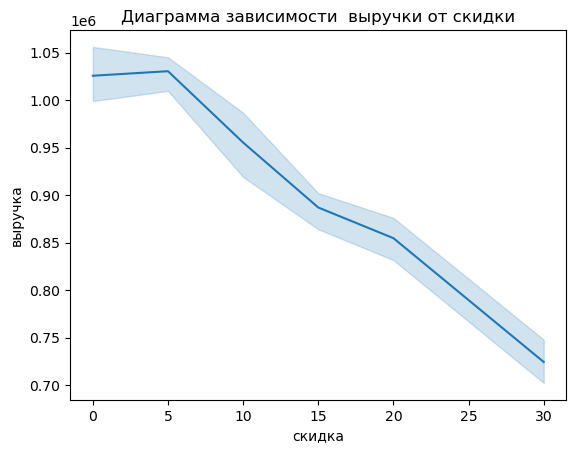

In [72]:
import seaborn as sns
gr=sns.lineplot(data=a, x='discount_percent', y='sum(total_revenue)')
gr.set_title("Диаграмма зависимости  выручки от скидки")
gr.set_ylabel('выручка')
gr.set_xlabel("скидка")##Вывести гистограмму по возрасту пассажиров

In [73]:
##Таким образом мы выяснили, что если необходимо установить одну скидку на все товары, то наиболее оптимальная скидка 5%

In [79]:
##Реалистичное  ОТношение "многие ко многим" в футболе придумать затруднительно поэтому пусть это будут самолеты- один футболист может владеть несколькими самолётами а один самолет модет перевозить несколько этих богатых пассажиров:)
players_planes = [
    'Boeing 767',
    'Airbus A340',
    'Ил-114',
]  

planes_df = pd.DataFrame({'plans_name': players_planes})
planes_df.to_sql('planes', sql, index_label="id", if_exists='replace')

3

In [80]:
pd.read_sql('SELECT * FROM planes', sql)

,id,plans_name
0,0,Boeing 767
1,1,Airbus A340
2,2,Ил-114


In [81]:
##Создаем промежуточную таблицу

In [90]:
players_id = [0,0,1,1,2,3,4,5,5,6]
planes_id = [0,1,0,1,0,0,1,1,2,2]
cross_table_df = pd.DataFrame({'players_id': players_id,'planes_id':planes_id})
cross_table_df.to_sql('cross_table', sql, index_label="id", if_exists='replace')

10

In [91]:
pd.read_sql('SELECT * FROM cross_table', sql)

,id,players_id,planes_id
0,0,0,0
1,1,0,1
2,2,1,0
3,3,1,1
4,4,2,0
5,5,3,0
6,6,4,1
7,7,5,1
8,8,5,2
9,9,6,2


In [92]:
pd.read_sql('''SELECT players.name,planes.plans_name FROM cross_table 
JOIN players ON cross_table.players_id=players.id
JOIN planes ON cross_table.planes_id=planes.id
''', sql)


,name,plans_name
0,Cristiano Ronaldu,Boeing 767
1,Cristiano Ronaldu,Airbus A340
2,Lionel Messi,Boeing 767
3,Lionel Messi,Airbus A340
4,Luca Modrich,Boeing 767
5,Dzanluidji de Buffon,Boeing 767
6,Kilian Mbape,Airbus A340
7,Artem Dzyba,Airbus A340
8,Artem Dzyba,Ил-114
9,Matvey Savonov,Ил-114
